In [1]:
!pip install opencv-python
import cv2
import matplotlib.pyplot as plt

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
    --------------------------------------- 0.5/40.2 MB 1.7 MB/s eta 0:00:24
    --------------------------------------- 0.8/40.2 MB 1.7 MB/s eta 0:00:23
   - -------------------------------------- 1.0/40.2 MB 1.4 MB/s eta 0:00:29
   - -------------------------------------- 1.3/40.2 MB 1.3 MB/s eta 0:00:30
   - -------------------------------------- 1.6/40.2 MB 1.3 MB/s eta 0:00:31
   - -------------------------------------- 1.8/40.2 MB 1.2 MB/s eta 0:00:32
   - -------------------------------------- 1.8/40.2 MB 1.2 MB/s eta 0:00:32
   -- ------------------------------------- 2.1/40.2 MB 1.1 MB/s eta 0:00:34
   -- ------------------------------------- 2.4/40.2 MB 1.1 MB/s eta 0:00:34
   -- ------------------------------------- 2.6/40.2 MB 1.1 MB/s eta 0:00:34
   --- ------------------------------------ 3.1/40.2 MB 1.2 MB/s eta 0:00:31
   --- ------

In [2]:
config_file = "ssd_mobilenet_v3_large_coco_2020_01_14.pbtxt"
frozen_model = "frozen_inference_graph.pb"

In [3]:
model = cv2.dnn_DetectionModel(frozen_model, config_file)

In [4]:
classLabels = []
file_name = 'labels.txt'
with open(file_name, 'rt') as fpt:
 classLabels = fpt.read().rstrip('\n').split('\n')
print(classLabels)

['person', 'bicycle', 'car', 'motorbike', 'aeroplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'sofa', 'pottedplant', 'bed', 'diningtable', 'toilet', 'tvmonitor', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']


In [5]:
print(len(classLabels)) 

80


In [6]:
model.setInputSize(320,320)
model.setInputScale(1.0/127.5)
model.setInputMean((127.5, 127, 5, 127.5))

< cv2.dnn.Model 00000207A8395B70>

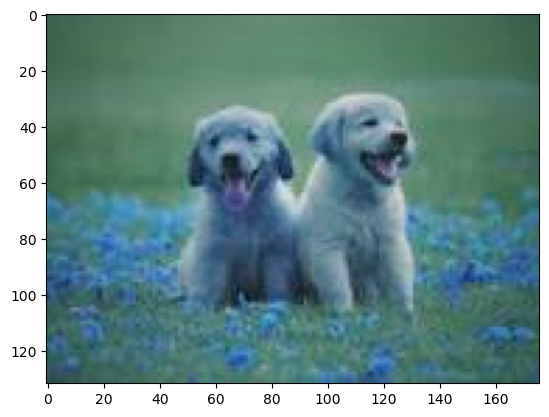

In [7]:
img = cv2.imread('dog.jpeg')
plt.imshow(img)

In [8]:
ClassIndex, Confidence, bbox = model.detect(img, confThreshold=0.5)

In [9]:
print(ClassIndex)

[18 18  1]


In [10]:
font_scale = 3
font = cv2.FONT_HERSHEY_PLAIN
for ClassInd, conf, boxes in zip(ClassIndex.flatten(), Confidence.flatten(), bbox):
 cv2.rectangle(img, boxes, (255,0,0),2)
 cv2.putText(img, classLabels[ClassInd-1], (boxes[0]+10, boxes[1]+10), font,
fontScale = font_scale, color = (0))

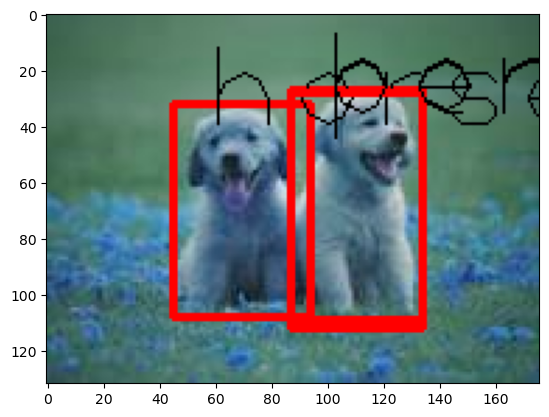

In [11]:
plt.imshow(img)